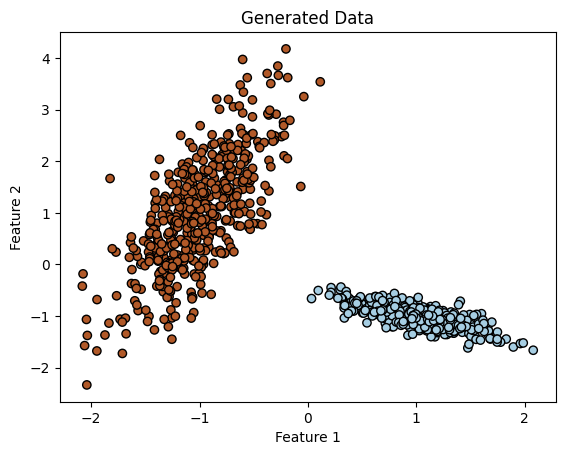

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


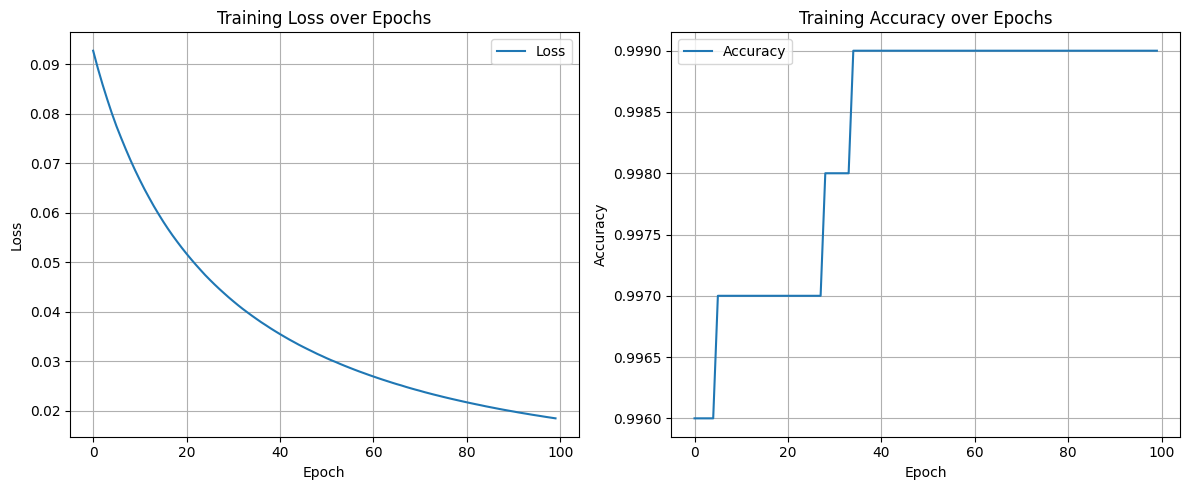

4114/4114 ━━━━━━━━━━━━━━━━━━━━ 4s 907us/step


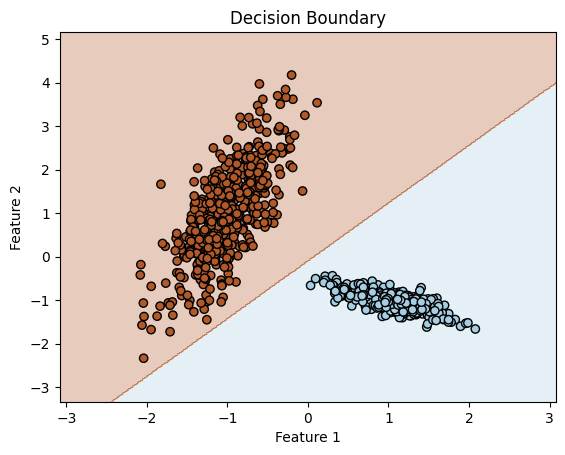

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def plot_data(X, y):
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='Paired')
    plt.title("Generated Data")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

def plot_decision_boundary(predict_func, X, y):
    # Set min and max values and give it some padding
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.02  # step size in the mesh

    # Generate a grid of points
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict the function value for the whole grid
    Z_probs = predict_func(np.c_[xx.ravel(), yy.ravel()])
    Z = (Z_probs > 0.5).astype("int32") # For Keras sigmoid output
    Z = Z.reshape(xx.shape)

    # Plot the contour and training points
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='Paired')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='Paired')
    plt.title("Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()


X, y = make_classification(n_samples=1000, n_features=2, n_redundant=0,
                           n_informative=2, random_state=7, n_clusters_per_class=1)
plot_data(X, y)

model = Sequential()
model.add(Dense(units=1, input_shape=(2,), activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Assuming plot_loss_accuracy is defined elsewhere, or will be addressed.
history = model.fit(x=X, y=y, verbose=0, epochs=100)
plot_loss_accuracy(history)
plot_decision_boundary(lambda x: model.predict(x), X, y)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


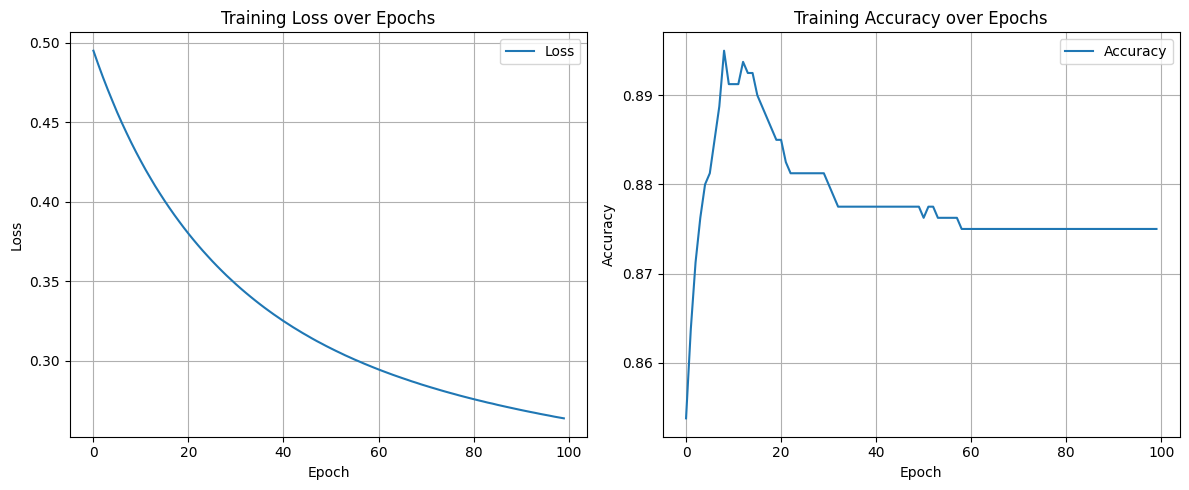

3562/3562 ━━━━━━━━━━━━━━━━━━━━ 3s 909us/step


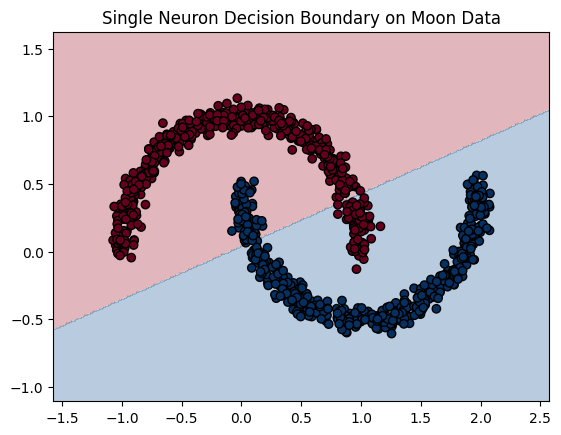

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Generate Complex "Moons" Data
X, y = make_moons(n_samples=1000, noise=0.05, random_state=0)

# 2. Split into Training and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create a Single-Layer, Single-Neuron Model
model = Sequential()
# One neuron, two inputs (x, y coordinates), and sigmoid activation
model.add(Dense(units=1, input_shape=(2,), activation='sigmoid'))

# 4. Compile the Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Train the Model
history = model.fit(X_train, y_train, epochs=100, verbose=0)
plot_loss_accuracy(history)

# 6. Visualization function to show the linear boundary
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Predict over the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = (Z > 0.5).astype(int)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='RdBu')
    plt.title("Single Neuron Decision Boundary on Moon Data")
    plt.show()

plot_decision_boundary(X, y, model)


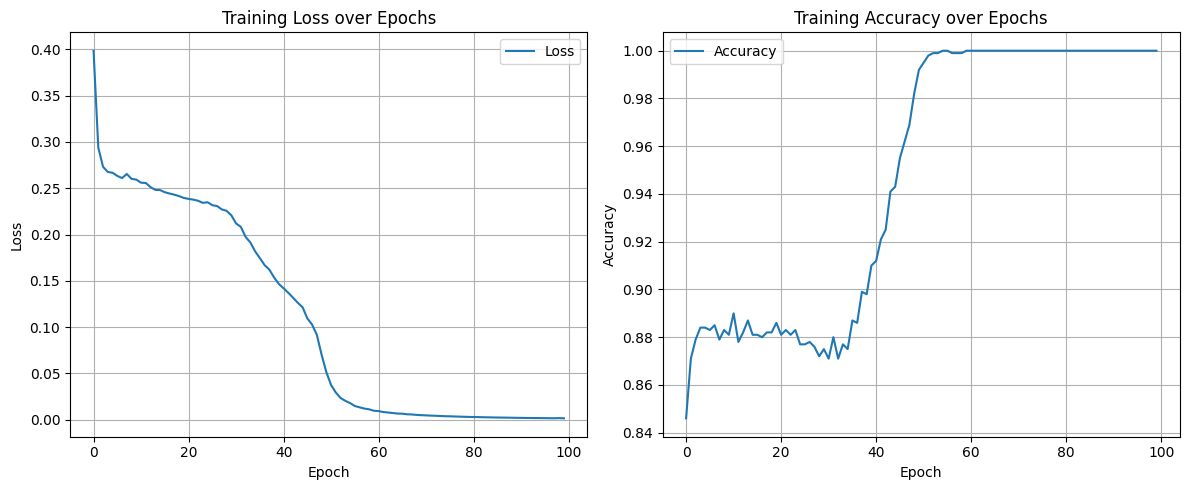

3562/3562 ━━━━━━━━━━━━━━━━━━━━ 3s 954us/step


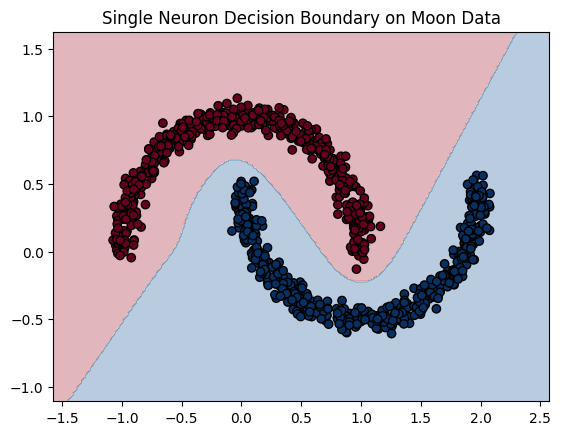

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Generate Complex "Moons" Data
X, y = make_moons(n_samples=1000, noise=0.05, random_state=0)

# 2. Split into Training and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create a Single-Layer, Single-Neuron Model
# model = Sequential()
# # One neuron, two inputs (x, y coordinates), and sigmoid activation
# model.add(Dense(units=1, input_shape=(2,), activation='sigmoid'))

model = Sequential()
model.add(Dense(4, input_shape=(2,), activation='tanh'))
model.add(Dense(2, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

model.compile(Adam(learning_rate=0.01), 'binary_crossentropy', metrics=['accuracy'])

history = model.fit(X, y, verbose=0, epochs=100)



# # 4. Compile the Model
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# # 5. Train the Model
# history = model.fit(X_train, y_train, epochs=100, verbose=0)
plot_loss_accuracy(history)

# 6. Visualization function to show the linear boundary
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Predict over the grid
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = (Z > 0.5).astype(int)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='RdBu')
    plt.title("Single Neuron Decision Boundary on Moon Data")
    plt.show()

plot_decision_boundary(X, y, model)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


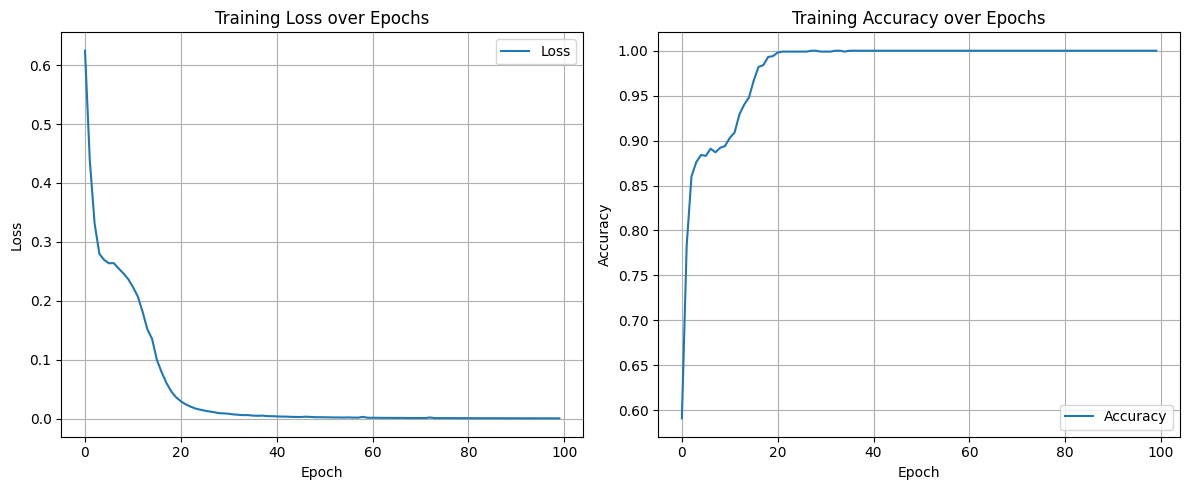

In [ ]:
from tensorflow.keras.optimizers import Adam

X, y = make_moons(n_samples=1000, noise=0.05, random_state=0)

model = Sequential()
model.add(Dense(4, input_shape=(2,), activation='tanh'))
model.add(Dense(2, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

model.compile(Adam(learning_rate=0.01), 'binary_crossentropy', metrics=['accuracy'])

history = model.fit(X, y, verbose=0, epochs=100)

plot_loss_accuracy(history)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


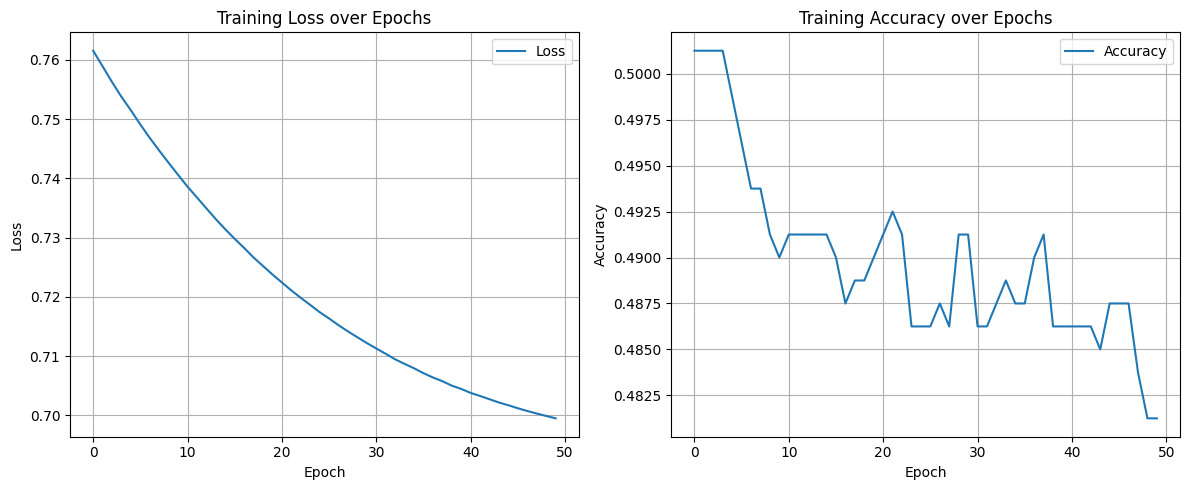

3200/3200 ━━━━━━━━━━━━━━━━━━━━ 3s 937us/step


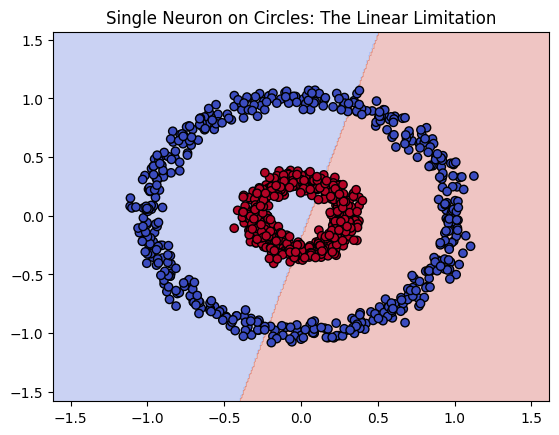

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 1. Generate "Circles" Data
# factor=0.3 creates a large gap between the inner and outer circle
X, y = make_circles(n_samples=1000, noise=0.05, factor=0.3, random_state=0)

# 2. Split into Training and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Create a Sequential Model (Logistic Regression)
model = Sequential()
# One neuron with sigmoid activation
model.add(Dense(units=1, input_shape=(2,), activation='sigmoid'))

# 4. Compile the Model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 5. Train the Model
history = model.fit(X_train, y_train, epochs=50, verbose=0)
plot_loss_accuracy(history)

# 6. Visualization function
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Predict and threshold at 0.5
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = (Z > 0.5).astype(int)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm')
    plt.title("Single Neuron on Circles: The Linear Limitation")
    plt.show()

plot_decision_boundary(X, y, model)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


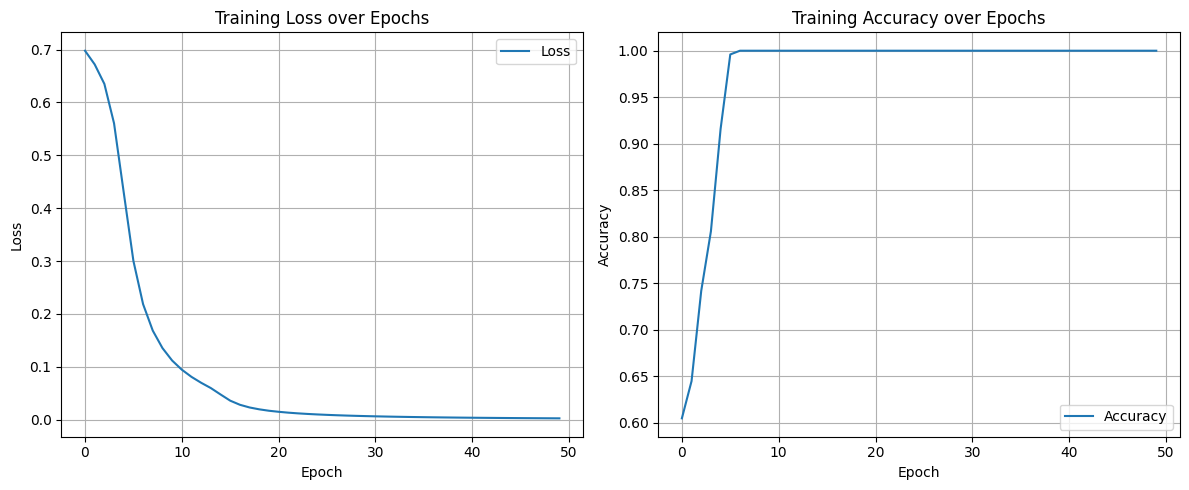

3200/3200 ━━━━━━━━━━━━━━━━━━━━ 3s 957us/step


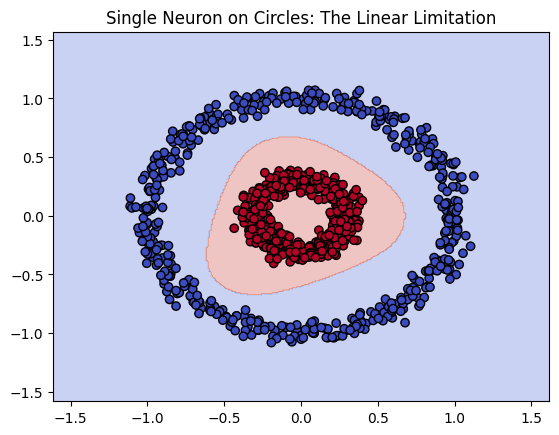

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

# 1. Generate "Circles" Data
# factor=0.3 creates a large gap between the inner and outer circle
X, y = make_circles(n_samples=1000, noise=0.05, factor=0.3, random_state=0)

# 2. Split into Training and Test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# # 3. Create a Sequential Model (Logistic Regression)
# # One neuron with sigmoid activation
# model.add(Dense(units=1, input_shape=(2,), activation='sigmoid'))

model = Sequential()
model.add(Dense(4, input_shape=(2,), activation='tanh'))
model.add(Dense(2, activation='tanh'))
model.add(Dense(1, activation='sigmoid'))

# 4. Compile the Model
# model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.compile(Adam(learning_rate=0.01), 'binary_crossentropy', metrics=['accuracy'])
# 5. Train the Model
# history = model.fit(X_train, y_train, epochs=50, verbose=0)
history = model.fit(X, y, verbose=0, epochs=50)
plot_loss_accuracy(history)

# 6. Visualization function
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))

    # Predict and threshold at 0.5
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = (Z > 0.5).astype(int)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap='coolwarm')
    plt.title("Single Neuron on Circles: The Linear Limitation")
    plt.show()

plot_decision_boundary(X, y, model)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


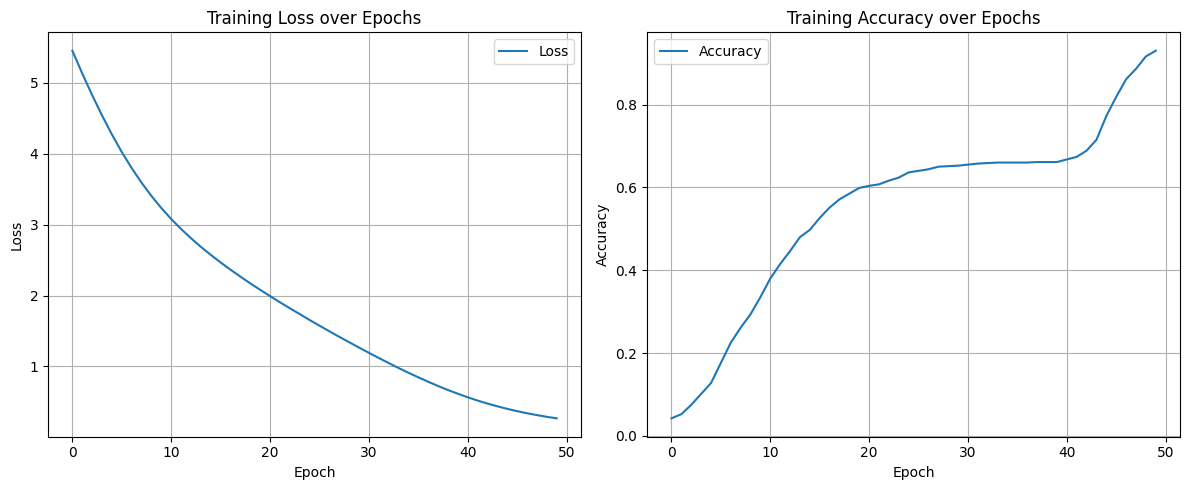

36279/36279 ━━━━━━━━━━━━━━━━━━━━ 36s 985us/step


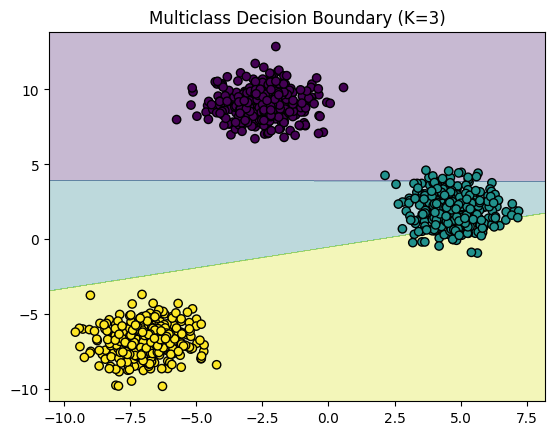

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

# 1. Custom function to generate multiclass data
def make_multiclass(K=3, n_samples=1000):
    from sklearn.datasets import make_blobs
    # Generates clusters (blobs) for K distinct classes
    X, y = make_blobs(n_samples=n_samples, centers=K, n_features=2, random_state=42)
    return X, y

# 2. Generate the data using your requested function
X, y = make_multiclass(K=3)

# 3. Preprocess for the Neural Network
# Convert labels (0, 1, 2) into One-Hot Encoding
y_categorical = to_categorical(y, num_classes=3)

X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# 4. Create a Single-Layer Multiclass Model
model = Sequential()
# Units must equal K (3) to provide a score for each class
# Softmax ensures the outputs sum to 1.0 (probabilities)
model.add(Dense(units=3, input_dim=2, activation='softmax'))

# 5. Compile the Model
# Categorical crossentropy is required for multiclass targets
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 6. Train the Model
history = model.fit(X_train, y_train, epochs=50, verbose=0)
plot_loss_accuracy(history)

# 7. Visualization of Decision Boundaries
def plot_multiclass_boundary(X, y_orig, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    h = 0.02  # step size in the mesh

    # Generate a grid of points
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    # Predict and use argmax to find the predicted class index
    predictions = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = np.argmax(predictions, axis=1)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y_orig, edgecolors='k', cmap='viridis')
    plt.title("Multiclass Decision Boundary (K=3)")
    plt.show()

plot_multiclass_boundary(X, y, model)